In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Iris dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!

Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [3]:
print("Dataset Information:")
print("="*40)
print(df.info())

print("\nStatistical Summary:")
print("="*40)
print(df.describe())

print("\nMissing Values:")
print("="*40)
print(df.isnull().sum())

print("\nSpecies Distribution:")
print("="*40)
print(df['species'].value_counts())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB
None

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%     

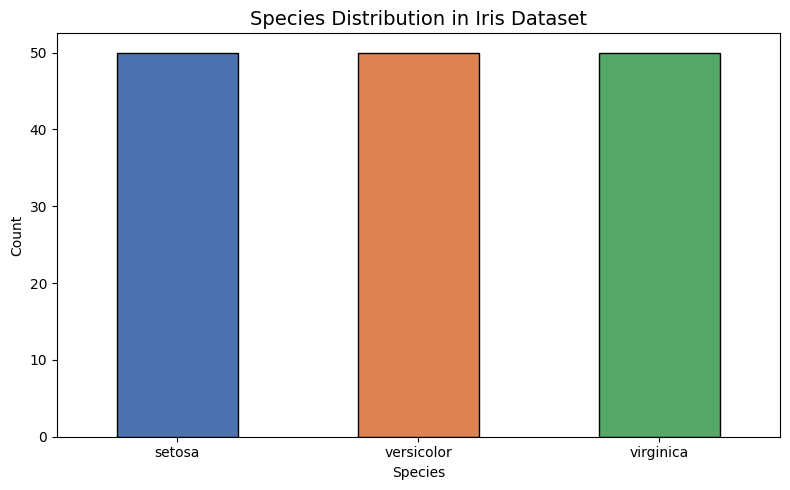

Chart saved!


In [4]:
plt.figure(figsize=(8, 5))
df['species'].value_counts().plot(
    kind='bar',
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='black'
)
plt.title("Species Distribution in Iris Dataset", fontsize=14)
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("D:/data-visualization/species_distribution.png", dpi=150)
plt.show()
print("Chart saved!")

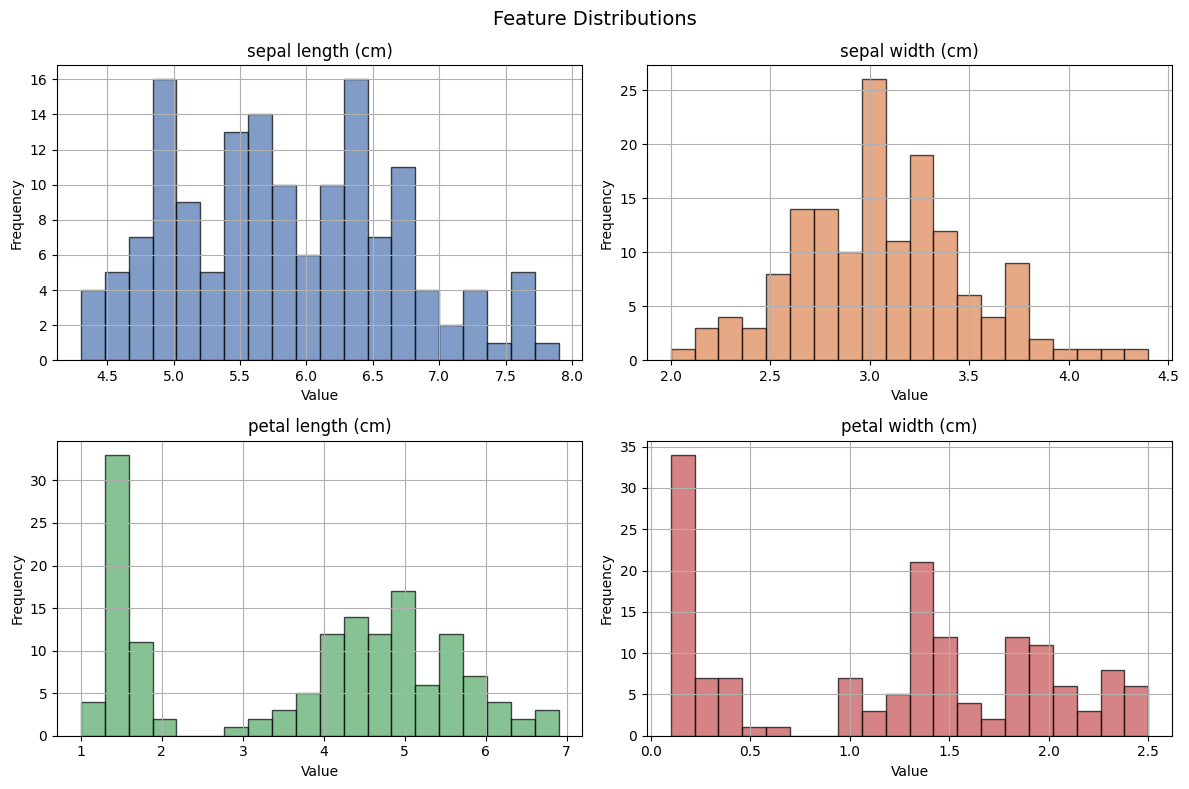

Chart saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = iris.feature_names
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (ax, feature, color) in enumerate(zip(axes.flatten(), features, colors)):
    df[feature].hist(ax=ax, bins=20, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(feature, fontsize=12)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("D:/data-visualization/feature_distributions.png", dpi=150)
plt.show()
print("Chart saved!")

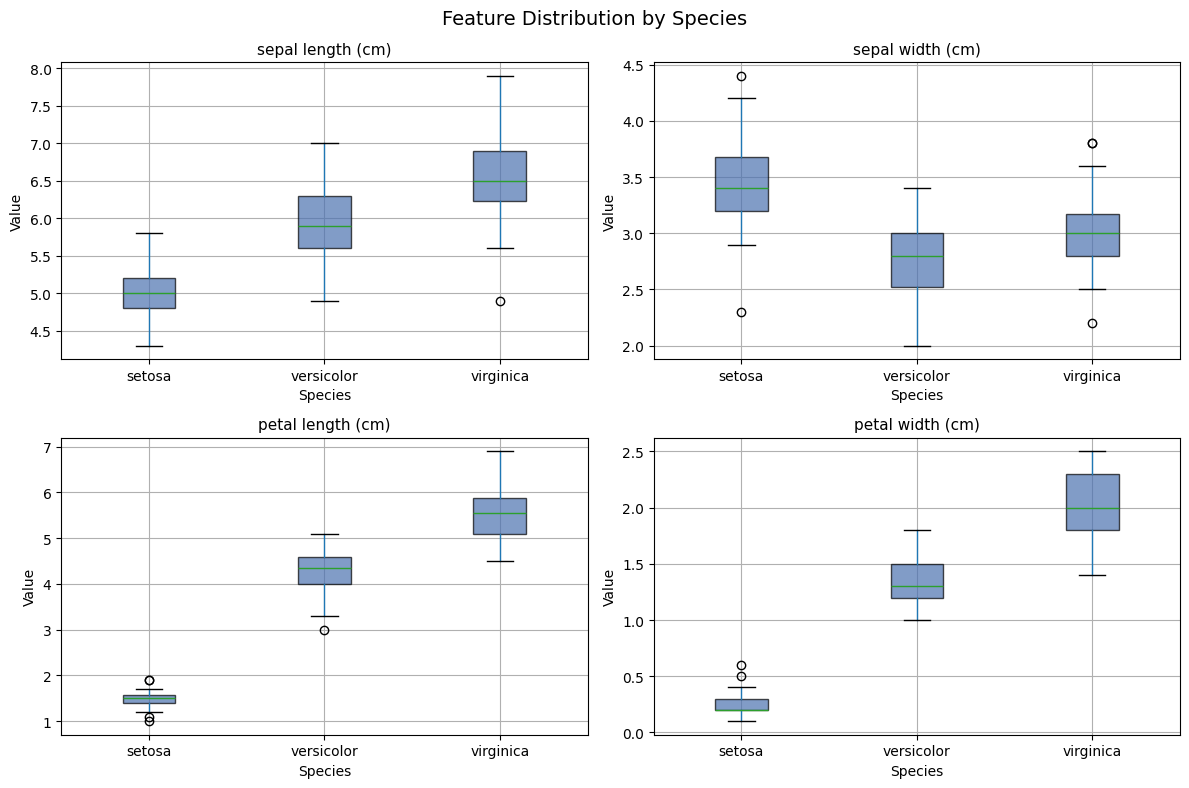

Chart saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (ax, feature) in enumerate(zip(axes.flatten(), features)):
    df.boxplot(column=feature, by='species', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("Species")
    ax.set_ylabel("Value")

plt.suptitle("Feature Distribution by Species", fontsize=14)
plt.tight_layout()
plt.savefig("D:/data-visualization/boxplots.png", dpi=150)
plt.show()
print("Chart saved!")

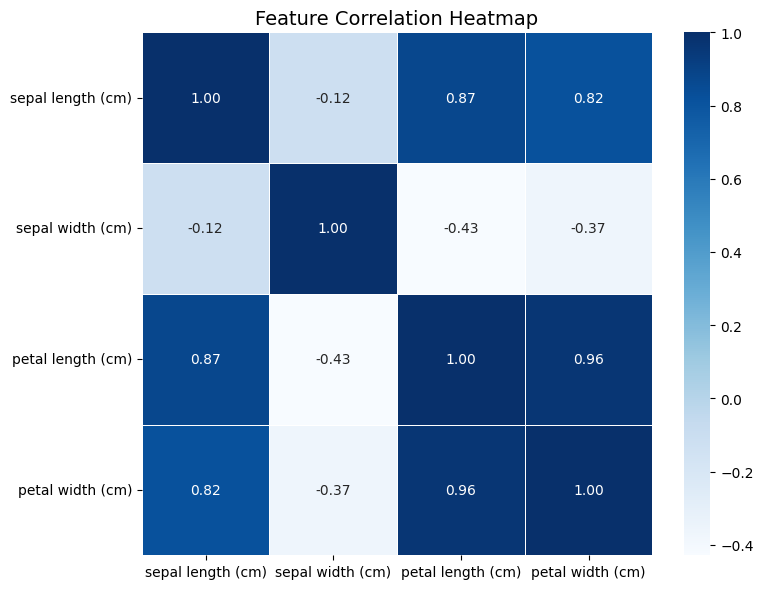

Chart saved!


In [7]:
plt.figure(figsize=(8, 6))
correlation = df.drop('species', axis=1).corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("D:/data-visualization/correlation_heatmap.png", dpi=150)
plt.show()
print("Chart saved!")

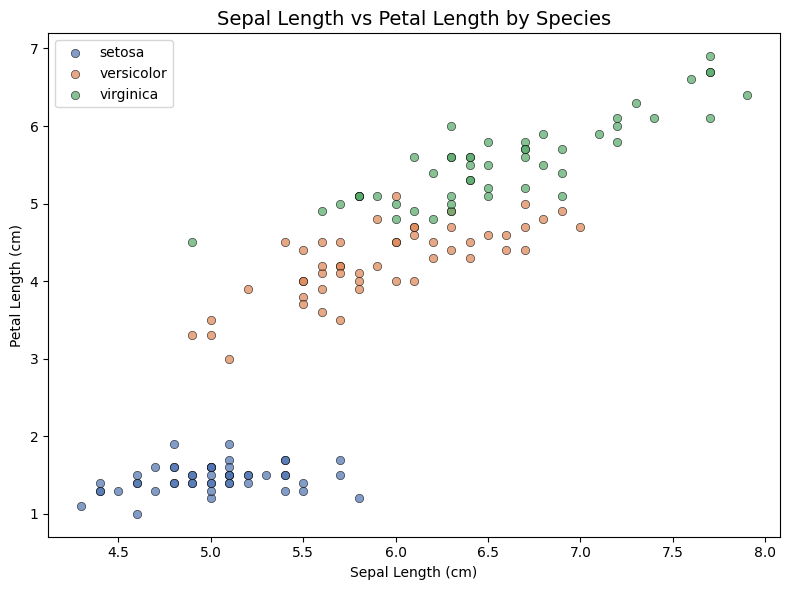

Chart saved!


In [8]:
plt.figure(figsize=(8, 6))

colors = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

for species, color in colors.items():
    subset = df[df['species'] == species]
    plt.scatter(
        subset['sepal length (cm)'],
        subset['petal length (cm)'],
        label=species,
        color=color,
        alpha=0.7,
        edgecolors='black',
        linewidths=0.5
    )

plt.title("Sepal Length vs Petal Length by Species", fontsize=14)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend()
plt.tight_layout()
plt.savefig("D:/data-visualization/scatter_plot.png", dpi=150)
plt.show()
print("Chart saved!")

<Figure size 640x480 with 0 Axes>

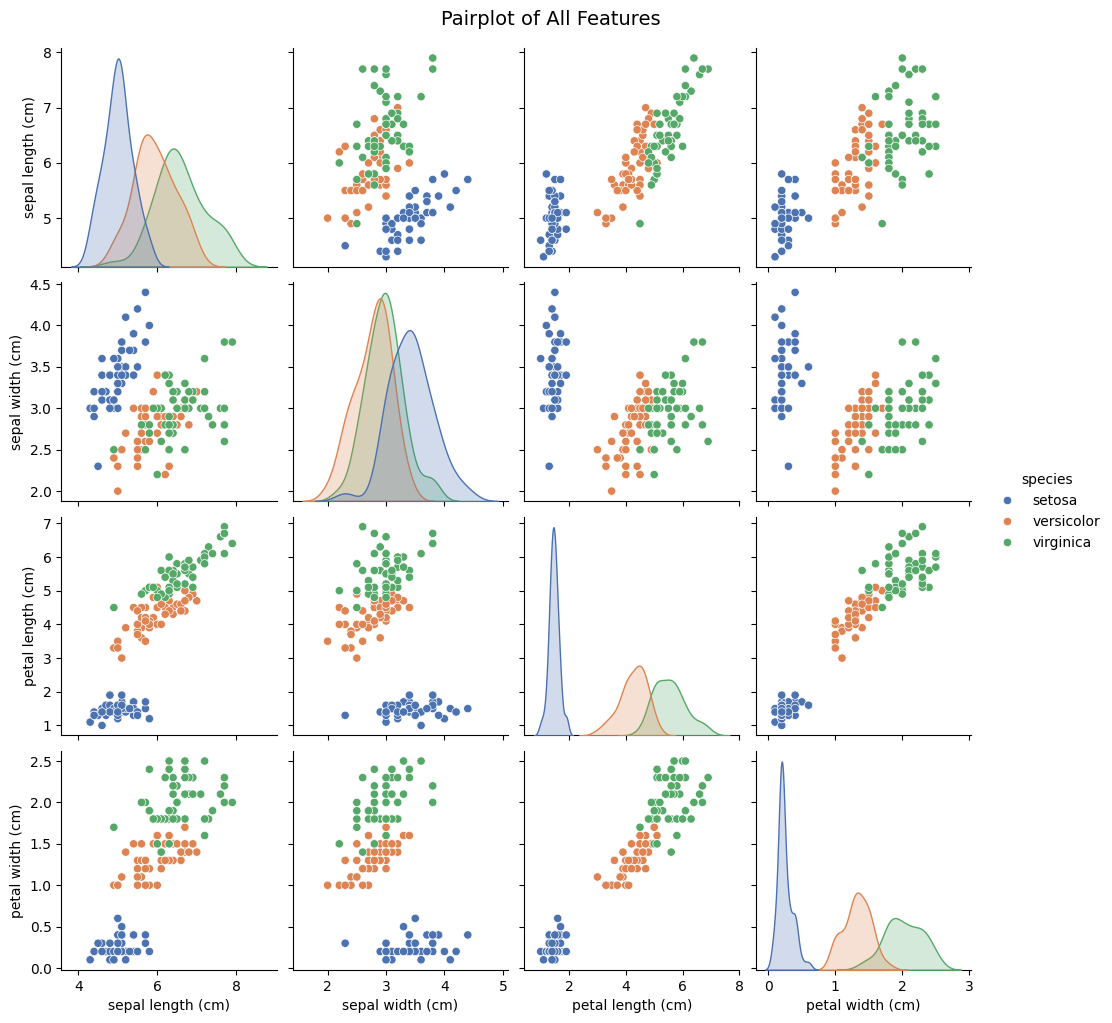

Chart saved!


In [9]:
plt.figure()
pair = sns.pairplot(
    df,
    hue='species',
    palette={'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'},
    diag_kind='kde'
)
pair.fig.suptitle("Pairplot of All Features", y=1.02, fontsize=14)
plt.savefig("D:/data-visualization/pairplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [10]:
print("=" * 50)
print("  DATA EXPLORATION & VISUALIZATION SUMMARY")
print("=" * 50)

print("""
OBJECTIVE:
  Explore and visualize the Iris dataset to extract
  meaningful insights using various chart types.

DATASET:
  Iris Dataset (scikit-learn)
  150 samples | 4 features | 3 species

FEATURES:
  - Sepal Length
  - Sepal Width
  - Petal Length
  - Petal Width

VISUALIZATIONS CREATED:
  1. Species Distribution Bar Chart
  2. Feature Histograms
  3. Boxplots by Species
  4. Correlation Heatmap
  5. Scatter Plot
  6. Pairplot

KEY INSIGHTS:
  - Dataset is perfectly balanced (50 samples per species)
  - Petal length and width are highly correlated
  - Setosa is clearly separable from the other two species
  - Versicolor and Virginica show some overlap
  - Petal features are more useful for classification than sepal features
""")

  DATA EXPLORATION & VISUALIZATION SUMMARY

OBJECTIVE:
  Explore and visualize the Iris dataset to extract
  meaningful insights using various chart types.

DATASET:
  Iris Dataset (scikit-learn)
  150 samples | 4 features | 3 species

FEATURES:
  - Sepal Length
  - Sepal Width
  - Petal Length
  - Petal Width

VISUALIZATIONS CREATED:
  1. Species Distribution Bar Chart
  2. Feature Histograms
  3. Boxplots by Species
  4. Correlation Heatmap
  5. Scatter Plot
  6. Pairplot

KEY INSIGHTS:
  - Dataset is perfectly balanced (50 samples per species)
  - Petal length and width are highly correlated
  - Setosa is clearly separable from the other two species
  - Versicolor and Virginica show some overlap
  - Petal features are more useful for classification than sepal features

